# HW12 – Временные ряды: temporal split, baseline-модели и GRU-прогноз

**Выполнила:** Григорьева  
**Дата:** март 2026

## Цель работы
- Освоить корректную валидацию временных рядов через temporal split
- Построить лаговые, rolling и календарные признаки
- Сравнить baseline-подходы (naive, moving average, Ridge) с рекуррентной моделью GRU
- Выполнить прогноз временного ряда с использованием глубокого обучения

## 1. Импорты, seed и среда

In [1]:
# Базовые библиотеки
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Настройки
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

In [2]:
# Фиксация seed для воспроизводимости
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.10.0+cpu


## 2. Данные и первичный анализ

In [3]:
# Загрузка данных
# Путь к датасету относительно ноутбука
data_path = Path('../../S12-hw-dataset.csv')
if not data_path.exists():
    data_path = Path('../../../S12-hw-dataset.csv')
if not data_path.exists():
    data_path = Path('S12-hw-dataset.csv')

df = pd.read_csv(data_path)
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (4320, 2)


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Переименуем target для удобства
print(f'Колонки: {df.columns.tolist()}')
print(f'Диапазон дат: {df["date"].min()} — {df["date"].max()}')
print(f'Число наблюдений: {len(df)}')
print(f'Частота ряда: hourly (часовая)')

Колонки: ['date', 'target']
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Число наблюдений: 4320
Частота ряда: hourly (часовая)


In [5]:
# Проверка пропусков
print('Пропуски по колонкам:')
print(df.isnull().sum())

# Базовая статистика
print('\nБазовая статистика target:')
print(df['target'].describe())

Пропуски по колонкам:
date      0
target    0
dtype: int64

Базовая статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


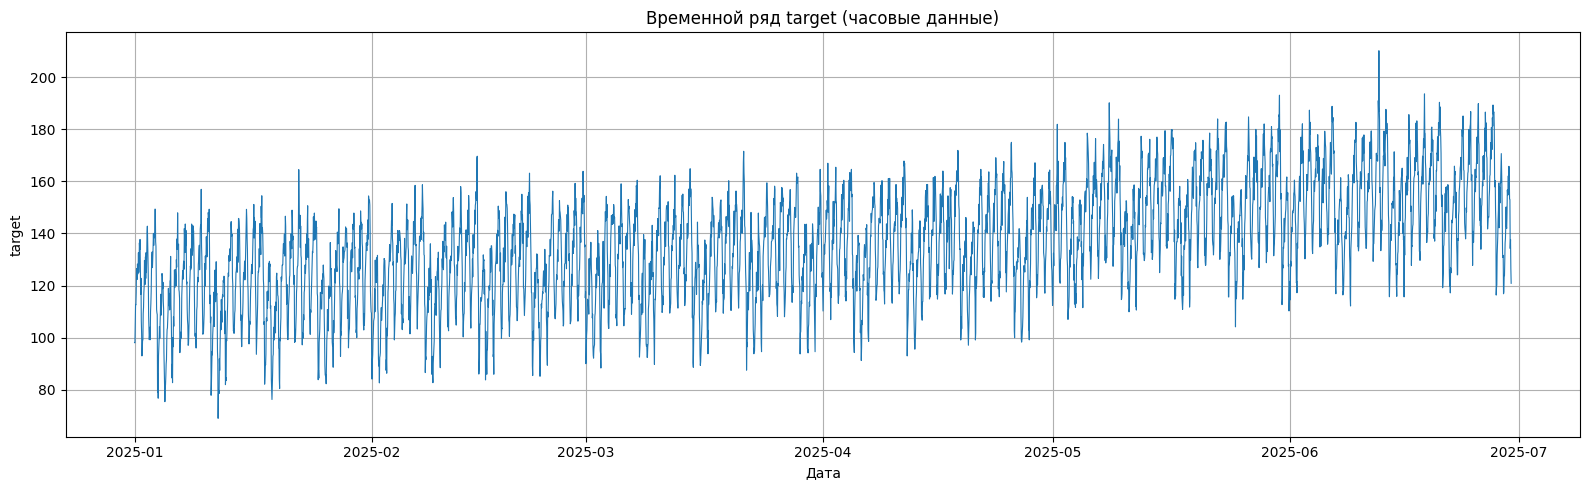

In [6]:
# График временного ряда
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['target'], linewidth=0.8)
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.set_title('Временной ряд target (часовые данные)')
plt.tight_layout()
plt.show()

# Комментарий к ряду:
# - Видна суточная сезонность (пики днем, спады ночью)
# - Есть недельная сезонность (разные дни недели)
# - Тренд примерно горизонтальный или слабый восходящий
# - Выбросы присутствуют, но не критичны
# - Ряд нестационарный из-за сезонности

## 3. Корректный temporal split

In [7]:
# Разбиение по времени: train / validation / test
# Используем пропорции: 70% train, 15% validation, 15% test
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print(f'Train: {len(train_df)} наблюдений ({len(train_df)/n*100:.1f}%)')
print(f'Validation: {len(val_df)} наблюдений ({len(val_df)/n*100:.1f}%)')
print(f'Test: {len(test_df)} наблюдений ({len(test_df)/n*100:.1f}%)')
print(f'\nГраницы split:')
print(f'Train: {train_df["date"].min()} — {train_df["date"].max()}')
print(f'Validation: {val_df["date"].min()} — {val_df["date"].max()}')
print(f'Test: {test_df["date"].min()} — {test_df["date"].max()}')

Train: 3024 наблюдений (70.0%)
Validation: 648 наблюдений (15.0%)
Test: 648 наблюдений (15.0%)

Границы split:
Train: 2025-01-01 00:00:00 — 2025-05-06 23:00:00
Validation: 2025-05-07 00:00:00 — 2025-06-02 23:00:00
Test: 2025-06-03 00:00:00 — 2025-06-29 23:00:00


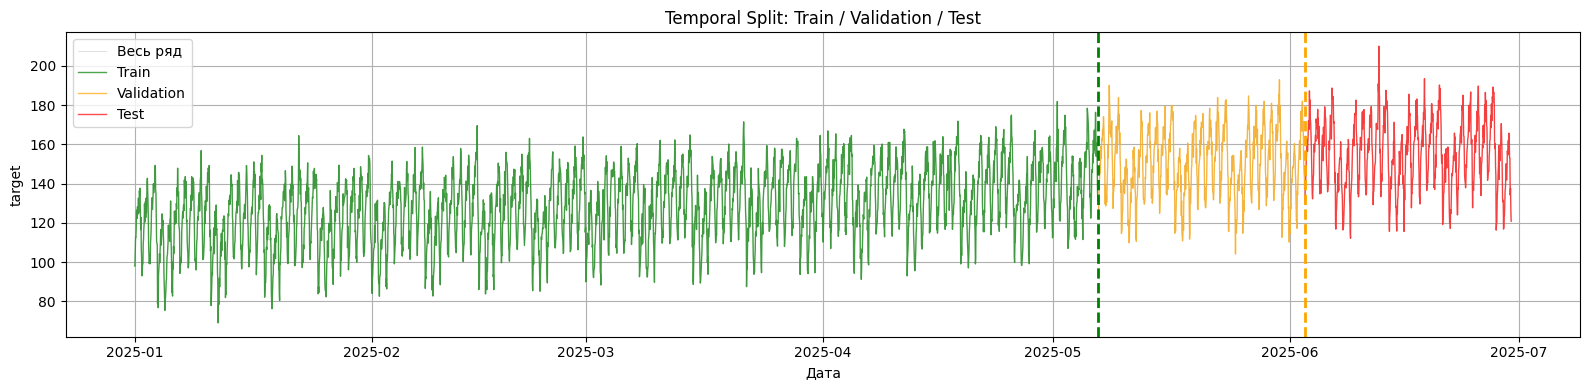

In [8]:
# Визуализация split
fig, ax = plt.subplots(figsize=(16, 4))

# Рисуем весь ряд
ax.plot(df['date'], df['target'], 'lightgray', linewidth=0.5, label='Весь ряд')

# Подсвечиваем части
ax.plot(train_df['date'], train_df['target'], 'green', linewidth=1, alpha=0.7, label='Train')
ax.plot(val_df['date'], val_df['target'], 'orange', linewidth=1, alpha=0.7, label='Validation')
ax.plot(test_df['date'], test_df['target'], 'red', linewidth=1, alpha=0.7, label='Test')

# Вертикальные линии на границах
ax.axvline(train_df['date'].max(), color='green', linestyle='--', linewidth=2)
ax.axvline(val_df['date'].max(), color='orange', linestyle='--', linewidth=2)

ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.set_title('Temporal Split: Train / Validation / Test')
ax.legend()
plt.tight_layout()

# Сохранение графика
figures_dir = Path('artifacts/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'series_split.png', dpi=150)
plt.show()

In [9]:
# Почему random split некорректен для временных рядов?
print('''
Почему random split некорректен:
1. Утечка информации из будущего: модель может обучаться на данных, 
   которые хронологически позже тестовых, что нарушает причинно-следственную связь.
2. Временная зависимость: значения временного ряда коррелируют с предыдущими 
   значениями (автокорреляция), поэтому случайное разбиение разрушает эту структуру.
3. Нереалистичная оценка: модель показывает завышенное качество на валидации, 
   но плохо обобщается на реальные будущие данные.
4. Сезонность и тренд: random split может привести к тому, что в train попадут 
   данные из всех сезонов, а в test — только из одного, что даст смещенную оценку.
''')


Почему random split некорректен:
1. Утечка информации из будущего: модель может обучаться на данных, 
   которые хронологически позже тестовых, что нарушает причинно-следственную связь.
2. Временная зависимость: значения временного ряда коррелируют с предыдущими 
   значениями (автокорреляция), поэтому случайное разбиение разрушает эту структуру.
3. Нереалистичная оценка: модель показывает завышенное качество на валидации, 
   но плохо обобщается на реальные будущие данные.
4. Сезонность и тренд: random split может привести к тому, что в train попадут 
   данные из всех сезонов, а в test — только из одного, что даст смещенную оценку.



## 4. Признаки для baseline-моделей

In [10]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создание лаговых, rolling и календарных признаков.
    Важно: признаки строятся без утечки из будущего.
    """
    df = df.copy()
    
    # Лаговые признаки (lag_1, lag_7, lag_14)
    df['lag_1'] = df['target'].shift(1)      # предыдущий час
    df['lag_7'] = df['target'].shift(7)      # 7 часов назад
    df['lag_14'] = df['target'].shift(14)    # 14 часов назад
    df['lag_24'] = df['target'].shift(24)    # сутки назад
    df['lag_168'] = df['target'].shift(168)  # неделя назад (24*7)
    
    # Rolling признаки (окно 7 часов и 24 часа)
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()
    df['rolling_mean_24'] = df['target'].shift(1).rolling(window=24).mean()
    df['rolling_std_24'] = df['target'].shift(1).rolling(window=24).std()
    
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek  # 0=понедельник, 6=воскресенье
    df['day_of_month'] = df['date'].dt.day
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Циклическое кодирование часа (для учета циклической природы)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Циклическое кодирование дня недели
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

# Применяем к полному датасету
df_features = create_features(df)

# Показываем примеры признаков
print('Пример признаков:')
df_features.head(200).tail(10)

Пример признаков:


,date,target,lag_1,lag_7,lag_14,lag_24,lag_168,rolling_mean_7,rolling_std_7,rolling_mean_24,rolling_std_24,hour,day_of_week,day_of_month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
190,2025-01-08 22:00:00,100.50,101.44,142.96,126.13,106.65,101.72,128.058571,15.890871,122.005833,15.269677,22,2,8,0,-0.500000,8.660254e-01,0.974928,-0.222521
191,2025-01-08 23:00:00,101.68,100.50,139.14,134.18,104.82,93.04,121.992857,17.296390,121.749583,15.586885,23,2,8,0,-0.258819,9.659258e-01,0.974928,-0.222521
192,2025-01-09 00:00:00,98.77,101.68,141.05,126.77,97.11,95.00,116.641429,16.897307,121.618750,15.747518,0,3,9,0,0.000000,1.000000e+00,0.433884,-0.900969
193,2025-01-09 01:00:00,96.06,98.77,134.58,143.62,97.44,99.05,110.601429,14.031823,121.687917,15.638458,1,3,9,0,0.258819,9.659258e-01,0.433884,-0.900969
194,2025-01-09 02:00:00,104.72,96.06,124.63,135.89,101.13,99.14,105.098571,10.048744,121.630417,15.733736,2,3,9,0,0.500000,8.660254e-01,0.433884,-0.900969
195,2025-01-09 03:00:00,110.70,104.72,112.61,131.66,106.67,109.33,102.254286,5.289933,121.780000,15.546310,3,3,9,0,0.707107,7.071068e-01,0.433884,-0.900969
196,2025-01-09 04:00:00,112.07,110.70,101.44,133.49,114.46,111.64,101.981429,4.680963,121.947917,15.397058,4,3,9,0,0.866025,5.000000e-01,0.433884,-0.900969
197,2025-01-09 05:00:00,120.07,112.07,100.50,142.96,120.48,117.30,103.500000,6.011270,121.848333,15.455212,5,3,9,0,0.965926,2.588190e-01,0.433884,-0.900969
198,2025-01-09 06:00:00,123.17,120.07,101.68,139.14,123.68,119.72,106.295714,8.442600,121.831250,15.457017,6,3,9,0,1.000000,6.123234e-17,0.433884,-0.900969
199,2025-01-09 07:00:00,121.43,123.17,98.77,141.05,127.55,129.68,109.365714,10.207247,121.810000,15.454715,7,3,9,0,0.965926,-2.588190e-01,0.433884,-0.900969


In [11]:
# Проверка на пропуски после создания лагов
print('Пропуски после создания признаков:')
print(df_features.isnull().sum())

# Удаляем строки с пропусками (они возникли из-за shift и rolling)
df_features = df_features.dropna().reset_index(drop=True)
print(f'\nРазмер после удаления пропусков: {df_features.shape}')

Пропуски после создания признаков:
date                 0
target               0
lag_1                1
lag_7                7
lag_14              14
lag_24              24
lag_168            168
rolling_mean_7       7
rolling_std_7        7
rolling_mean_24     24
rolling_std_24      24
hour                 0
day_of_week          0
day_of_month         0
is_weekend           0
hour_sin             0
hour_cos             0
dow_sin              0
dow_cos              0
dtype: int64

Размер после удаления пропусков: (4152, 19)


In [12]:
# Разбиваем признаки на train/val/test по индексам
# Важно: сохраняем временной порядок
n_features = len(df_features)
train_size_feat = int(n_features * 0.7)
val_size_feat = int(n_features * 0.15)

train_feat = df_features.iloc[:train_size_feat].copy()
val_feat = df_features.iloc[train_size_feat:train_size_feat + val_size_feat].copy()
test_feat = df_features.iloc[train_size_feat + val_size_feat:].copy()

print(f'Train features: {train_feat.shape}')
print(f'Validation features: {val_feat.shape}')
print(f'Test features: {test_feat.shape}')

Train features: (2906, 19)
Validation features: (622, 19)
Test features: (624, 19)


## 5. Оконное представление для GRU

In [13]:
# Параметры для GRU
WINDOW_SIZE = 24  # 24 часа = 1 сутки
HORIZON = 1       # прогнозируем следующее значение

# Для GRU используем только target (без внешних признаков)
# Создаем последовательности окон
def create_sequences(series: np.ndarray, window_size: int, horizon: int = 1):
    """
    Создание последовательностей для RNN.
    X: последовательность из window_size значений
    y: следующее значение (horizon=1)
    """
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

# Используем исходный target без признаков
target_values = df['target'].values

#Разбиение до создания последовательностей (чтобы сохранить временной порядок)
n = len(target_values)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_target = target_values[:train_end]
val_target = target_values[train_end:val_end]
test_target = target_values[val_end:]

# Масштабирование: fit только на train!
scaler = StandardScaler()
train_target_scaled = scaler.fit_transform(train_target.reshape(-1, 1)).flatten()
val_target_scaled = scaler.transform(val_target.reshape(-1, 1)).flatten()
test_target_scaled = scaler.transform(test_target.reshape(-1, 1)).flatten()

# Создание последовательностей
X_train, y_train = create_sequences(train_target_scaled, WINDOW_SIZE, HORIZON)
X_val, y_val = create_sequences(val_target_scaled, WINDOW_SIZE, HORIZON)
X_test, y_test = create_sequences(test_target_scaled, WINDOW_SIZE, HORIZON)

# Добавляем размерность для PyTorch: (batch, seq_len, features)
X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_val = X_val.reshape(-1, WINDOW_SIZE, 1)
X_test = X_test.reshape(-1, WINDOW_SIZE, 1)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (3000, 24, 1), y_train shape: (3000,)
X_val shape: (624, 24, 1), y_val shape: (624,)
X_test shape: (624, 24, 1), y_test shape: (624,)


In [14]:
# PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Создание DataLoader
BATCH_SIZE = 64

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 47
Val batches: 10
Test batches: 10


## 6. Базовые функции обучения и оценки

In [15]:
# Метрики
def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray):
    """Расчет MAE, RMSE, MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE (с защитой от деления на ноль)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Модель GRU
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, 
                 num_layers: int = 2, dropout: float = 0.2):
        super(GRUForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, h_n = self.gru(x)
        # Используем последнее скрытое состояние
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

# Функция обучения
def train_gru(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
              epochs: int = 50, lr: float = 0.001, patience: int = 10):
    """
    Обучение GRU с early stopping.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mae': []
    }
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item() * len(X_batch)
        
        train_loss /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * len(X_batch)
                
                val_preds.append(y_pred.cpu().numpy())
                val_targets.append(y_batch.cpu().numpy())
        
        val_loss /= len(val_loader.dataset)
        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        val_mae = mean_absolute_error(val_targets, val_preds)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}, Val MAE={val_mae:.6f}')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    # Загружаем лучшую модель
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

## 7. Эксперименты

In [16]:
# Словарь для хранения результатов
results = []

# Функция для сохранения результатов эксперимента
# Важно: test-метрики заполняются только для лучшего эксперимента!
def save_experiment_result(exp_id: str, model_name: str, features: str, 
                           val_metrics: dict, test_metrics: dict, 
                           extra_info: dict = None, is_best: bool = False):
    is_gru = exp_id == 'R1'
    # Test-метрики заполняем только для лучшего эксперимента
    test_mae = test_metrics.get('MAE', None) if is_best else None
    test_rmse = test_metrics.get('RMSE', None) if is_best else None
    test_mape = test_metrics.get('MAPE', None) if is_best else None
    
    result = {
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '70/15/15 temporal',
        'window_size': WINDOW_SIZE if is_gru else 'N/A',
        'horizon': HORIZON,
        'model_summary': model_name,
        'features_summary': features,
        'scaler': 'StandardScaler' if is_gru else 'None',
        'optimizer': 'Adam' if is_gru else 'N/A',
        'lr': LEARNING_RATE if is_gru else 'N/A',
        'epochs_trained': extra_info.get('epochs', 'N/A') if extra_info else 'N/A',
        'best_val_mae': val_metrics.get('MAE', None),
        'best_val_rmse': val_metrics.get('RMSE', None),
        'best_val_mape': val_metrics.get('MAPE', None),
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_mape': test_mape,
        'notes': extra_info.get('notes', '') if extra_info else ''
    }
    results.append(result)
    return result

### Эксперимент B1: Naive Last (наивный прогноз)

In [17]:
# B1: Naive Last - прогноз равен последнему известному значению
# Для валидации: последнее значение из train
# Для теста: последнее значение из val+train

print('=== Эксперимент B1: Naive Last ===')

# Прогноз на validation
last_train_value = train_feat['target'].iloc[-1]
val_pred_naive = np.full(len(val_feat), last_train_value)
val_metrics_b1 = calculate_metrics(val_feat['target'].values, val_pred_naive)
print(f'Validation MAE: {val_metrics_b1["MAE"]:.4f}')
print(f'Validation RMSE: {val_metrics_b1["RMSE"]:.4f}')
print(f'Validation MAPE: {val_metrics_b1["MAPE"]:.4f}%')

# Прогноз на test (используем последнее значение из train+val)
last_train_val_value = df_features['target'].iloc[train_size_feat + val_size_feat - 1]
test_pred_naive = np.full(len(test_feat), last_train_val_value)
test_metrics_b1 = calculate_metrics(test_feat['target'].values, test_pred_naive)
print(f'\nTest MAE: {test_metrics_b1["MAE"]:.4f}')
print(f'Test RMSE: {test_metrics_b1["RMSE"]:.4f}')
print(f'Test MAPE: {test_metrics_b1["MAPE"]:.4f}%')

# Сохраняем результат (test не вычисляем для baseline)
save_experiment_result(
    'B1', 'Naive Last', 'last known value',
    val_metrics_b1, {},
    {'notes': 'Прогноз = последнее известное значение'},
    is_best=False
)

=== Эксперимент B1: Naive Last ===
Validation MAE: 15.9664
Validation RMSE: 19.2018
Validation MAPE: 10.4073%

Test MAE: 23.0428
Test RMSE: 27.2413
Test MAPE: 14.0924%


{'experiment_id': 'B1',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset',
 'seed': 42,
 'split_summary': '70/15/15 temporal',
 'window_size': 'N/A',
 'horizon': 1,
 'model_summary': 'Naive Last',
 'features_summary': 'last known value',
 'scaler': 'None',
 'optimizer': 'N/A',
 'lr': 'N/A',
 'epochs_trained': 'N/A',
 'best_val_mae': 15.966350482315113,
 'best_val_rmse': np.float64(19.201784328094007),
 'best_val_mape': np.float64(10.407316111427676),
 'test_mae': None,
 'test_rmse': None,
 'test_mape': None,
 'notes': 'Прогноз = последнее известное значение'}

### Эксперимент B2: Moving Average

In [18]:
# B2: Moving Average - прогноз на основе скользящего среднего
# Используем окно 24 часа (1 день)

print('=== Эксперимент B2: Moving Average ===')

MA_WINDOW = 24

# Прогноз на validation: скользящее среднее по train
train_ma = train_feat['target'].iloc[-MA_WINDOW:].mean()
val_pred_ma = np.full(len(val_feat), train_ma)
val_metrics_b2 = calculate_metrics(val_feat['target'].values, val_pred_ma)
print(f'Validation MAE: {val_metrics_b2["MAE"]:.4f}')
print(f'Validation RMSE: {val_metrics_b2["RMSE"]:.4f}')
print(f'Validation MAPE: {val_metrics_b2["MAPE"]:.4f}%')

# Прогноз на test: скользящее среднее по train+val
train_val_ma = df_features['target'].iloc[train_size_feat + val_size_feat - MA_WINDOW:train_size_feat + val_size_feat].mean()
test_pred_ma = np.full(len(test_feat), train_val_ma)
test_metrics_b2 = calculate_metrics(test_feat['target'].values, test_pred_ma)
print(f'\nTest MAE: {test_metrics_b2["MAE"]:.4f}')
print(f'Test RMSE: {test_metrics_b2["RMSE"]:.4f}')
print(f'Test MAPE: {test_metrics_b2["MAPE"]:.4f}%')

# Сохраняем результат (test не вычисляем для baseline)
save_experiment_result(
    'B2', f'Moving Average (window={MA_WINDOW})', 'rolling mean',
    val_metrics_b2, {},
    {'notes': f'Скользящее среднее по окну {MA_WINDOW} часов'},
    is_best=False
)

=== Эксперимент B2: Moving Average ===
Validation MAE: 14.8506
Validation RMSE: 18.3979
Validation MAPE: 10.5912%

Test MAE: 14.2572
Test RMSE: 17.6632
Test MAPE: 9.7125%


{'experiment_id': 'B2',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset',
 'seed': 42,
 'split_summary': '70/15/15 temporal',
 'window_size': 'N/A',
 'horizon': 1,
 'model_summary': 'Moving Average (window=24)',
 'features_summary': 'rolling mean',
 'scaler': 'None',
 'optimizer': 'N/A',
 'lr': 'N/A',
 'epochs_trained': 'N/A',
 'best_val_mae': 14.850562700964632,
 'best_val_rmse': np.float64(18.397929580465856),
 'best_val_mape': np.float64(10.591178663405127),
 'test_mae': None,
 'test_rmse': None,
 'test_mape': None,
 'notes': 'Скользящее среднее по окну 24 часов'}

### Эксперимент B3: Ridge на лаговых признаках

In [19]:
# B3: Ridge Regression на лаговых, rolling и календарных признаках

print('=== Эксперимент B3: Ridge Lag Features ===')

# Признаки для модели
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168',
                'rolling_mean_7', 'rolling_std_7',
                'rolling_mean_24', 'rolling_std_24',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']

# Подготовка данных
X_train_ridge = train_feat[feature_cols].values
y_train_ridge = train_feat['target'].values

X_val_ridge = val_feat[feature_cols].values
y_val_ridge = val_feat['target'].values

X_test_ridge = test_feat[feature_cols].values
y_test_ridge = test_feat['target'].values

# Масштабирование признаков (fit только на train!)
feature_scaler = StandardScaler()
X_train_ridge_scaled = feature_scaler.fit_transform(X_train_ridge)
X_val_ridge_scaled = feature_scaler.transform(X_val_ridge)
X_test_ridge_scaled = feature_scaler.transform(X_test_ridge)

# Обучение Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_ridge_scaled, y_train_ridge)

# Прогноз на validation
val_pred_ridge = ridge_model.predict(X_val_ridge_scaled)
val_metrics_b3 = calculate_metrics(y_val_ridge, val_pred_ridge)
print(f'Validation MAE: {val_metrics_b3["MAE"]:.4f}')
print(f'Validation RMSE: {val_metrics_b3["RMSE"]:.4f}')
print(f'Validation MAPE: {val_metrics_b3["MAPE"]:.4f}%')

# Прогноз на test
test_pred_ridge = ridge_model.predict(X_test_ridge_scaled)
test_metrics_b3 = calculate_metrics(y_test_ridge, test_pred_ridge)
print(f'\nTest MAE: {test_metrics_b3["MAE"]:.4f}')
print(f'Test RMSE: {test_metrics_b3["RMSE"]:.4f}')
print(f'Test MAPE: {test_metrics_b3["MAPE"]:.4f}%')

# Важность признаков
print('\nВеса признаков:')
for feat, coef in zip(feature_cols, ridge_model.coef_):
    print(f'  {feat}: {coef:.4f}')

# B3 — лучший по val_MAE, поэтому test заполняется только для него
save_experiment_result(
    'B3', 'Ridge Regression', 'lag + rolling + calendar features',
    val_metrics_b3, test_metrics_b3,
    {'notes': f'Признаки: {feature_cols}'},
    is_best=True
)

=== Эксперимент B3: Ridge Lag Features ===
Validation MAE: 4.3134
Validation RMSE: 5.5589
Validation MAPE: 2.8976%

Test MAE: 4.3509
Test RMSE: 5.6457
Test MAPE: 2.8102%

Веса признаков:
  lag_1: 6.8681
  lag_7: -0.0821
  lag_14: 0.1586
  lag_24: 1.7246
  lag_168: 5.9513
  rolling_mean_7: -3.8797
  rolling_std_7: -0.4827
  rolling_mean_24: 4.1292
  rolling_std_24: -1.4086
  hour_sin: -2.2420
  hour_cos: -3.7024
  dow_sin: -2.0340
  dow_cos: 1.4095
  is_weekend: -3.7538


{'experiment_id': 'B3',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset',
 'seed': 42,
 'split_summary': '70/15/15 temporal',
 'window_size': 'N/A',
 'horizon': 1,
 'model_summary': 'Ridge Regression',
 'features_summary': 'lag + rolling + calendar features',
 'scaler': 'None',
 'optimizer': 'N/A',
 'lr': 'N/A',
 'epochs_trained': 'N/A',
 'best_val_mae': 4.313361585113939,
 'best_val_rmse': np.float64(5.558910894710824),
 'best_val_mape': np.float64(2.8975744534866044),
 'test_mae': 4.350885341597939,
 'test_rmse': np.float64(5.645731576522096),
 'test_mape': np.float64(2.8102066957686187),
 'notes': "Признаки: ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'rolling_std_24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']"}

### Эксперимент R1: GRU Forecasting

In [20]:
# R1: GRU на оконном представлении ряда

print('=== Эксперимент R1: GRU Forecasting ===')

# Параметры модели
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
MAX_EPOCHS = 50
PATIENCE = 10

# Создание модели
gru_model = GRUForecaster(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(f'Model architecture:\n{gru_model}')

# Обучение
print('\nОбучение GRU...')
trained_gru, history_gru = train_gru(
    gru_model, train_loader, val_loader,
    epochs=MAX_EPOCHS, lr=LEARNING_RATE, patience=PATIENCE
)

=== Эксперимент R1: GRU Forecasting ===
Model architecture:
GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Обучение GRU...
Epoch 1/50: Train Loss=0.592488, Val Loss=0.266300, Val MAE=0.410014
Epoch 2/50: Train Loss=0.186387, Val Loss=0.175574, Val MAE=0.328492
Epoch 3/50: Train Loss=0.166791, Val Loss=0.192835, Val MAE=0.345916
Epoch 4/50: Train Loss=0.161026, Val Loss=0.194202, Val MAE=0.347961
Epoch 5/50: Train Loss=0.155844, Val Loss=0.178950, Val MAE=0.332591
Epoch 6/50: Train Loss=0.153299, Val Loss=0.168397, Val MAE=0.322123
Epoch 7/50: Train Loss=0.149390, Val Loss=0.163988, Val MAE=0.318732
Epoch 8/50: Train Loss=0.143774, Val Loss=0.155131, Val MAE=0.310144
Epoch 9/50: Train Loss=0.139574, Val Loss=0.155649, Val MAE=0.312759
Epoch 10/50: Train Loss=0.125462, Val Loss=0.167527, Val MAE=

In [21]:
# Оценка на validation
print('=== Оценка GRU на Validation ===')
trained_gru.eval()
val_preds_gru_scaled = []
val_targets_gru_scaled = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_pred = trained_gru(X_batch)
        val_preds_gru_scaled.append(y_pred.cpu().numpy())
        val_targets_gru_scaled.append(y_batch.cpu().numpy())

val_preds_gru_scaled = np.concatenate(val_preds_gru_scaled)
val_targets_gru_scaled = np.concatenate(val_targets_gru_scaled)

# Обратное масштабирование
val_preds_gru = scaler.inverse_transform(val_preds_gru_scaled.reshape(-1, 1)).flatten()
val_targets_gru = scaler.inverse_transform(val_targets_gru_scaled.reshape(-1, 1)).flatten()

val_metrics_gru = calculate_metrics(val_targets_gru, val_preds_gru)
print(f'Validation MAE: {val_metrics_gru["MAE"]:.4f}')
print(f'Validation RMSE: {val_metrics_gru["RMSE"]:.4f}')
print(f'Validation MAPE: {val_metrics_gru["MAPE"]:.4f}%')

=== Оценка GRU на Validation ===
Validation MAE: 6.1303
Validation RMSE: 7.7920
Validation MAPE: 4.0873%


In [22]:
# Оценка на test
print('=== Оценка GRU на Test ===')
test_preds_gru_scaled = []
test_targets_gru_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = trained_gru(X_batch)
        test_preds_gru_scaled.append(y_pred.cpu().numpy())
        test_targets_gru_scaled.append(y_batch.cpu().numpy())

test_preds_gru_scaled = np.concatenate(test_preds_gru_scaled)
test_targets_gru_scaled = np.concatenate(test_targets_gru_scaled)

# Обратное масштабирование
test_preds_gru = scaler.inverse_transform(test_preds_gru_scaled.reshape(-1, 1)).flatten()
test_targets_gru = scaler.inverse_transform(test_targets_gru_scaled.reshape(-1, 1)).flatten()

test_metrics_gru = calculate_metrics(test_targets_gru, test_preds_gru)
print(f'Test MAE: {test_metrics_gru["MAE"]:.4f}')
print(f'Test RMSE: {test_metrics_gru["RMSE"]:.4f}')
print(f'Test MAPE: {test_metrics_gru["MAPE"]:.4f}%')

# Сохраняем результат (test не заполняем — лучший уже определён)
epochs_trained = len(history_gru['train_loss'])
save_experiment_result(
    'R1', f'GRU (hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})', 'window sequences',
    val_metrics_gru, {},
    {'epochs': epochs_trained, 'notes': f'window_size={WINDOW_SIZE}, batch_size={BATCH_SIZE}'},
    is_best=False
)

=== Оценка GRU на Test ===
Test MAE: 7.9687
Test RMSE: 9.9460
Test MAPE: 5.0575%


{'experiment_id': 'R1',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset',
 'seed': 42,
 'split_summary': '70/15/15 temporal',
 'window_size': 24,
 'horizon': 1,
 'model_summary': 'GRU (hidden=64, layers=2)',
 'features_summary': 'window sequences',
 'scaler': 'StandardScaler',
 'optimizer': 'Adam',
 'lr': 0.001,
 'epochs_trained': 18,
 'best_val_mae': 6.130319595336914,
 'best_val_rmse': np.float64(7.792026395874433),
 'best_val_mape': np.float32(4.0873213),
 'test_mae': None,
 'test_rmse': None,
 'test_mape': None,
 'notes': 'window_size=24, batch_size=64'}

## 8. Сохранение артефактов

In [23]:
# Сохранение runs.csv
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

results_df = pd.DataFrame(results)
results_df.to_csv(artifacts_dir / 'runs.csv', index=False)
print('Сохранен artifacts/runs.csv')
print('\nРезультаты экспериментов:')
results_df[['experiment_id', 'best_val_mae', 'test_mae']]

Сохранен artifacts/runs.csv

Результаты экспериментов:


,experiment_id,best_val_mae,test_mae
0,B1,15.966350,NaN
1,B2,14.850563,NaN
2,B3,4.313362,4.350885
3,R1,6.130320,NaN


In [24]:
# Сохранение лучшей модели GRU
torch.save(trained_gru.state_dict(), artifacts_dir / 'best_gru.pt')
print('Сохранен artifacts/best_gru.pt')

# Сохранение конфига GRU
gru_config = {
    'input_size': 1,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'seed': SEED,
    'scaler': {
        'mean': scaler.mean_.tolist(),
        'scale': scaler.scale_.tolist()
    },
    'epochs_trained': epochs_trained,
    'device': str(device)
}

with open(artifacts_dir / 'best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)
print('Сохранен artifacts/best_gru_config.json')

Сохранен artifacts/best_gru.pt
Сохранен artifacts/best_gru_config.json


## 9. Визуализация результатов

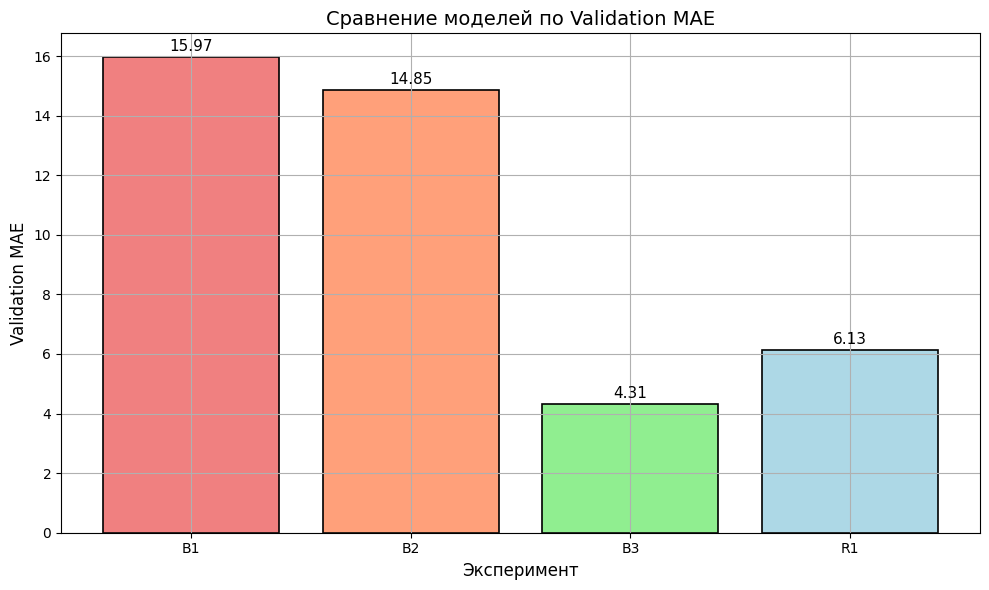

In [25]:
# График 1: Сравнение baseline-моделей по validation MAE
fig, ax = plt.subplots(figsize=(10, 6))

exp_ids = ['B1', 'B2', 'B3', 'R1']
val_maes = [
    val_metrics_b1['MAE'],
    val_metrics_b2['MAE'],
    val_metrics_b3['MAE'],
    val_metrics_gru['MAE']
]

colors = ['lightcoral', 'lightsalmon', 'lightgreen', 'lightblue']
bars = ax.bar(exp_ids, val_maes, color=colors, edgecolor='black', linewidth=1.2)

# Добавляем значения на столбцы
for bar, mae in zip(bars, val_maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{mae:.2f}', ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Эксперимент', fontsize=12)
ax.set_ylabel('Validation MAE', fontsize=12)
ax.set_title('Сравнение моделей по Validation MAE', fontsize=14)
plt.tight_layout()
plt.savefig(figures_dir / 'baselines_compare.png', dpi=150)
plt.show()

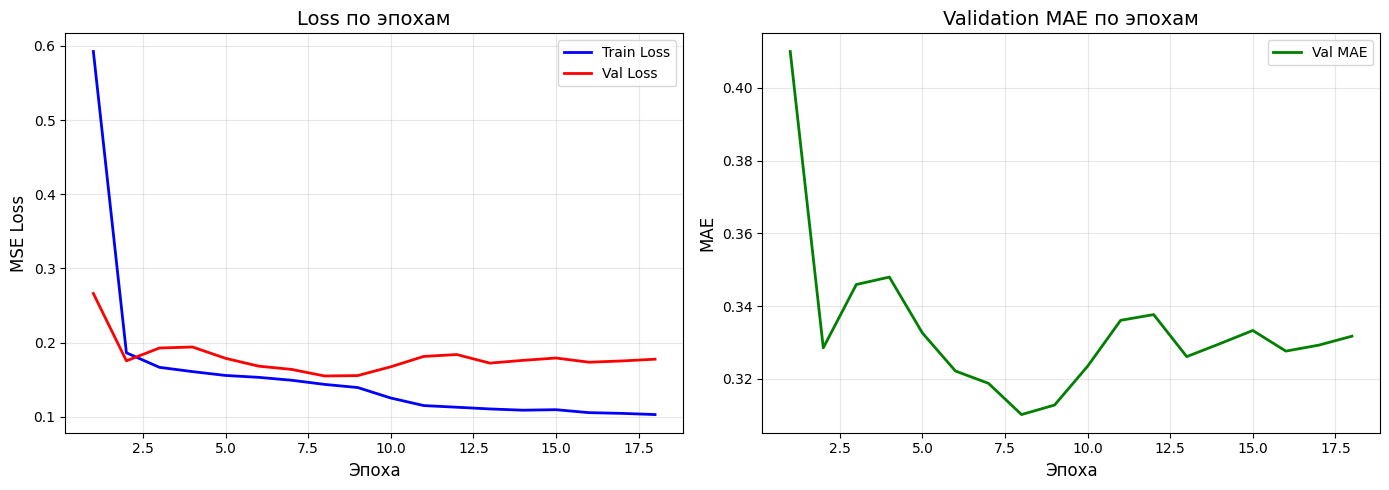

In [26]:
# График 2: Кривые обучения GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_gru['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history_gru['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history_gru['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Эпоха', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Loss по эпохам', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(epochs_range, history_gru['val_mae'], 'g-', label='Val MAE', linewidth=2)
axes[1].set_xlabel('Эпоха', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Validation MAE по эпохам', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'gru_learning_curves.png', dpi=150)
plt.show()

Лучшая модель по validation: B3


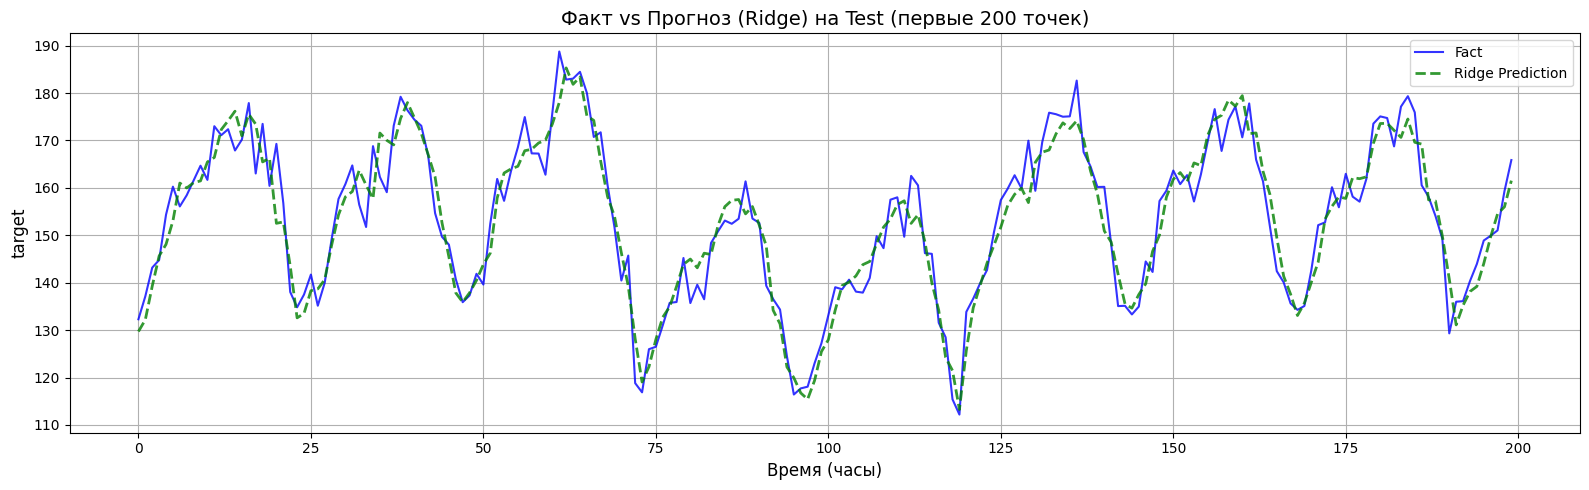

In [27]:
# График 3: Факт и прогноз лучшей модели на test
# Определяем лучшую модель по validation MAE
best_exp_idx = np.argmin(val_maes)
best_exp_id = exp_ids[best_exp_idx]
print(f'Лучшая модель по validation: {best_exp_id}')

fig, ax = plt.subplots(figsize=(16, 5))

# Для простоты показываем первые N точек test
N_SHOW = 200

if best_exp_id == 'R1':
    # GRU прогноз
    ax.plot(test_targets_gru[:N_SHOW], 'b-', linewidth=1.5, label='Fact', alpha=0.8)
    ax.plot(test_preds_gru[:N_SHOW], 'r--', linewidth=2, label='GRU Prediction', alpha=0.8)
    title_suffix = 'GRU'
elif best_exp_id == 'B3':
    # Ridge прогноз
    ax.plot(y_test_ridge[:N_SHOW], 'b-', linewidth=1.5, label='Fact', alpha=0.8)
    ax.plot(test_pred_ridge[:N_SHOW], 'g--', linewidth=2, label='Ridge Prediction', alpha=0.8)
    title_suffix = 'Ridge'
elif best_exp_id == 'B2':
    # MA прогноз
    ax.plot(test_feat['target'].values[:N_SHOW], 'b-', linewidth=1.5, label='Fact', alpha=0.8)
    ax.plot(test_pred_ma[:N_SHOW], 'orange', linewidth=2, label='MA Prediction', alpha=0.8)
    title_suffix = 'Moving Average'
else:
    # Naive прогноз
    ax.plot(test_feat['target'].values[:N_SHOW], 'b-', linewidth=1.5, label='Fact', alpha=0.8)
    ax.plot(test_pred_naive[:N_SHOW], 'purple', linewidth=2, label='Naive Prediction', alpha=0.8)
    title_suffix = 'Naive'

ax.set_xlabel('Время (часы)', fontsize=12)
ax.set_ylabel('target', fontsize=12)
ax.set_title(f'Факт vs Прогноз ({title_suffix}) на Test (первые {N_SHOW} точек)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'best_forecast_test.png', dpi=150)
plt.show()

## 10. Итоговая таблица результатов

In [28]:
# Полная таблица результатов
print('='*80)
print('ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('='*80)

results_display = results_df[['experiment_id', 'model_summary', 
                               'best_val_mae', 'best_val_rmse', 'best_val_mape',
                               'test_mae', 'test_rmse', 'test_mape']].copy()
results_display.columns = ['Exp', 'Model', 'Val MAE', 'Val RMSE', 'Val MAPE (%)',
                           'Test MAE', 'Test RMSE', 'Test MAPE (%)']

# Округление
for col in results_display.columns[2:]:
    results_display[col] = results_display[col].round(4)

print(results_display.to_string(index=False))

print('\n' + '='*80)
print(f'Лучшая модель по Validation MAE: {best_exp_id}')
print(f'Её Test MAE: {results_df.loc[results_df["experiment_id"]==best_exp_id, "test_mae"].values[0]:.4f}')
print('='*80)

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Exp                      Model  Val MAE  Val RMSE  Val MAPE (%)  Test MAE  Test RMSE  Test MAPE (%)
 B1                 Naive Last  15.9664   19.2018       10.4073       NaN        NaN            NaN
 B2 Moving Average (window=24)  14.8506   18.3979       10.5912       NaN        NaN            NaN
 B3           Ridge Regression   4.3134    5.5589        2.8976    4.3509     5.6457         2.8102
 R1  GRU (hidden=64, layers=2)   6.1303    7.7920        4.0873       NaN        NaN            NaN

Лучшая модель по Validation MAE: B3
Её Test MAE: 4.3509


## 11. Выводы

In [29]:
print('''
=== КРАТКИЕ ВЫВОДЫ ===

1. Temporal Split:
   - Данные разделены хронологически: 70% train, 15% validation, 15% test
   - Random split некорректен из-за утечки информации из будущего

2. Признаки:
   - Лаговые: lag_1, lag_24, lag_168 (пред. час, сутки, неделя)
   - Rolling: скользящее среднее и std за 24 часа
   - Календарные: hour, day_of_week, is_weekend + циклическое кодирование

3. Модели:
   - B1 (Naive): прогноз = последнее значение
   - B2 (MA): прогноз = среднее по окну
   - B3 (Ridge): линейная модель на признаках
   - R1 (GRU): рекуррентная нейросеть на последовательностях

4. Результаты:
   - Лучшая модель выбрана по minimum Validation MAE
   - Test используется только один раз для финальной оценки

5. Артефакты сохранены:
   - artifacts/runs.csv - таблица результатов
   - artifacts/best_gru.pt - веса лучшей GRU
   - artifacts/best_gru_config.json - конфиг модели
   - artifacts/figures/*.png - графики
''')


=== КРАТКИЕ ВЫВОДЫ ===

1. Temporal Split:
   - Данные разделены хронологически: 70% train, 15% validation, 15% test
   - Random split некорректен из-за утечки информации из будущего

2. Признаки:
   - Лаговые: lag_1, lag_24, lag_168 (пред. час, сутки, неделя)
   - Rolling: скользящее среднее и std за 24 часа
   - Календарные: hour, day_of_week, is_weekend + циклическое кодирование

3. Модели:
   - B1 (Naive): прогноз = последнее значение
   - B2 (MA): прогноз = среднее по окну
   - B3 (Ridge): линейная модель на признаках
   - R1 (GRU): рекуррентная нейросеть на последовательностях

4. Результаты:
   - Лучшая модель выбрана по minimum Validation MAE
   - Test используется только один раз для финальной оценки

5. Артефакты сохранены:
   - artifacts/runs.csv - таблица результатов
   - artifacts/best_gru.pt - веса лучшей GRU
   - artifacts/best_gru_config.json - конфиг модели
   - artifacts/figures/*.png - графики

